In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
# 1. Set path
data_dir = "/Users/rajthakur/Desktop/Raj/Animal_data"

In [3]:
# 2. Parameters
img_size = (128, 128)  # Resize all images to 128x128
batch_size = 32

In [4]:
# 3. Data preprocessing using ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% training, 20% validation
)

In [5]:
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)


Found 1771 images belonging to 17 classes.


In [6]:
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 435 images belonging to 17 classes.


In [7]:
# 4. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

/Users/rajthakur/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 5. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights)

Epoch 1/30


/Users/rajthakur/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.0694 - loss: 2.9337 - val_accuracy: 0.1747 - val_loss: 2.6493
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.1852 - loss: 2.6051 - val_accuracy: 0.2782 - val_loss: 2.4151
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.3227 - loss: 2.1946 - val_accuracy: 0.2966 - val_loss: 2.1850
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.4049 - loss: 1.8724 - val_accuracy: 0.3287 - val_loss: 2.1711
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.5044 - loss: 1.5206 - val_accuracy: 0.3195 - val_loss: 2.1696
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.6304 - loss: 1.1559 - val_accuracy: 0.3425 - val_loss: 2.3614
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.6799 - loss: 0.9536 - val_accuracy: 0.3586 - val_loss: 2.4028
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.7535 - loss: 0.7203 - val_accuracy: 0.333

In [10]:
# 7. Save the model
model.save("animal_cnn_model.h5")

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.8755 - loss: 0.2536 - val_accuracy: 0.3471 - val_loss: 5.0414
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.8578 - loss: 0.2711 - val_accuracy: 0.3379 - val_loss: 4.9397
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.8723 - loss: 0.2517 - val_accuracy: 0.3517 - val_loss: 4.6539
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.8706 - loss: 0.2560 - val_accuracy: 0.3126 - val_loss: 4.9944
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.8715 - loss: 0.2456 - val_accuracy: 0.3264 - val_loss: 5.2204
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.8640 - loss: 0.2370 - val_accuracy: 0.3494 - val_loss: 4.5734
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - accuracy: 0.8561 - loss: 0.2571 - val_accuracy: 0.3471 - val_loss: 5.2573
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 196ms/step - accuracy: 0.8766 - loss: 0.2269 - val_accu

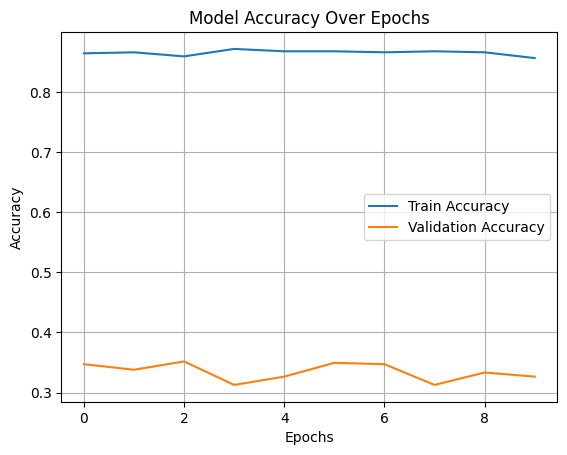

In [11]:
# This line trains your model and stores the history
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

import matplotlib.pyplot as plt

# Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [18]:
from tensorflow.keras.models import load_model


# Only run this ONCE at the beginning
model = load_model("animal_cnn_model.h5")

# Then run prediction on different images like this
def predict_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    class_labels = ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse',
                    'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']
    predicted_label = class_labels[predicted_class]

    # Show result
    plt.imshow(img)
    plt.title(f"Predicted class: {predicted_label}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


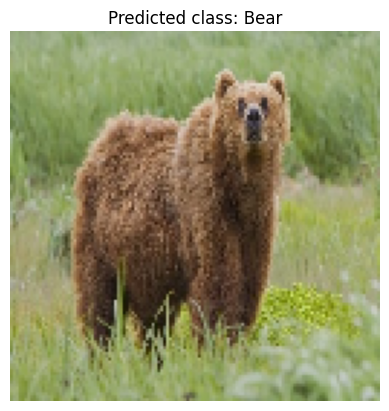

In [20]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/bear_1_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


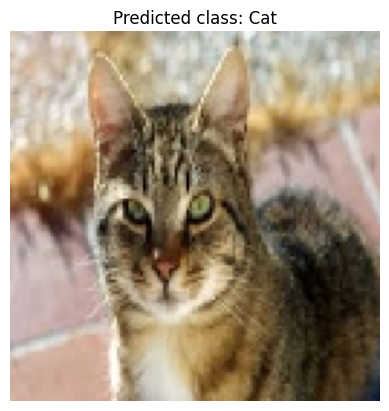

In [21]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Cat_1.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


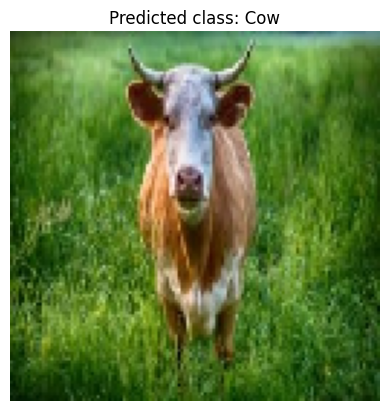

In [22]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Cow/Cow_4.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


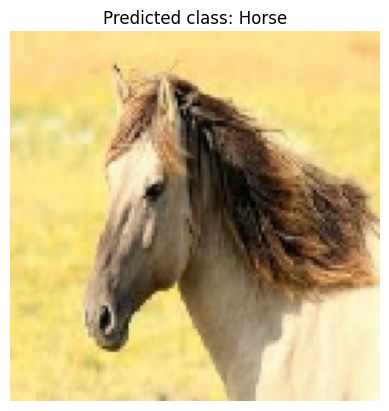

In [24]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Horse/Horse_25_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


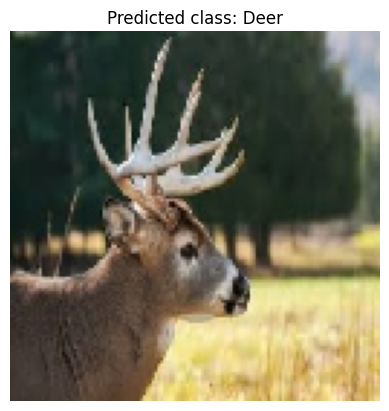

In [25]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Deer/Deer_6.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


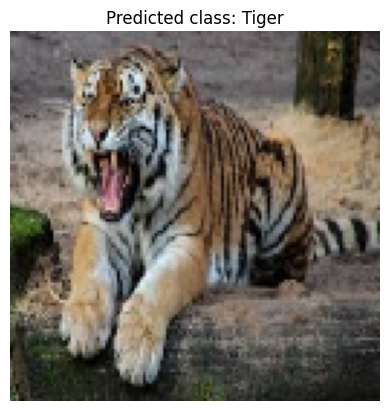

In [26]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Tiger/Tiger_17_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


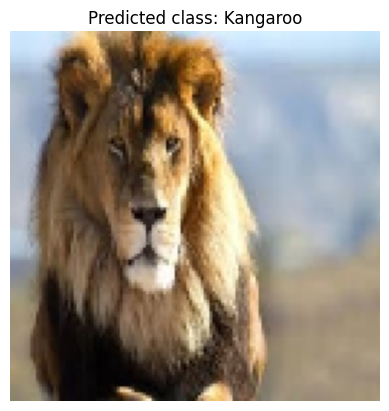

In [27]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Lion/Lion_15.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


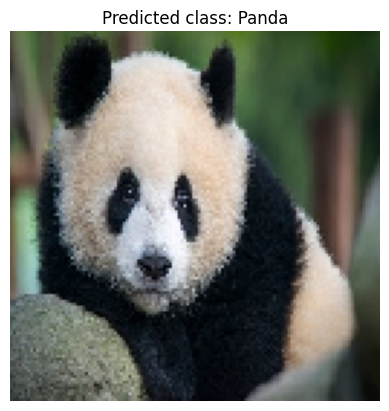

In [28]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Panda/Panda_3.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


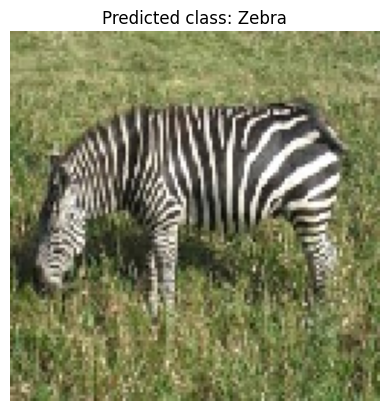

In [29]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Zebra/Zebra_22_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


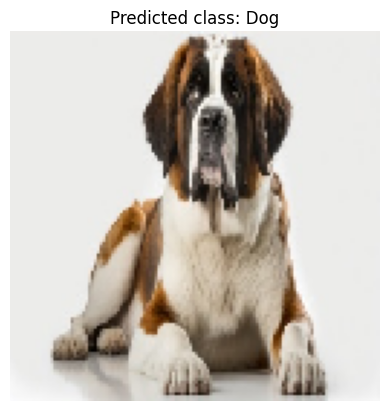

In [30]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Dog/Dog_8_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


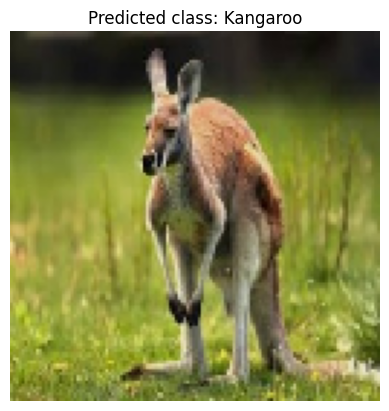

In [31]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Kangaroo/Kangaroo_26_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


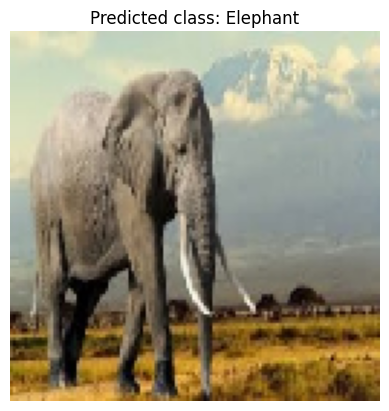

In [32]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Elephant/Elephant_20.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


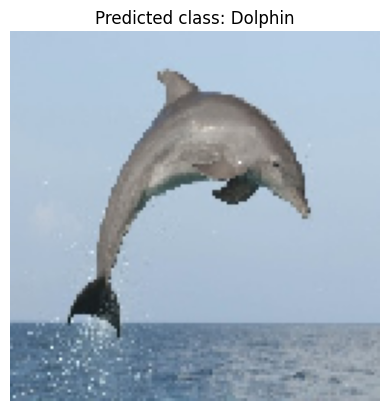

In [33]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Dolphin/Dolphin_7_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


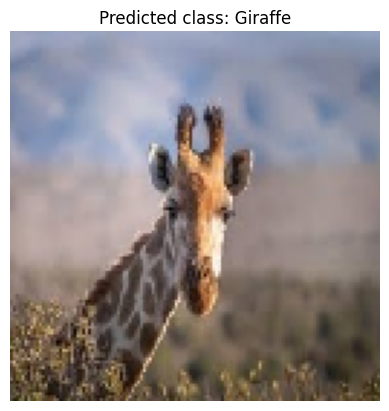

In [34]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Giraffe/Giraffe_3.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


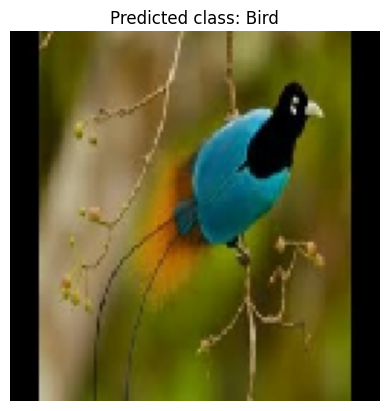

In [35]:
predict_image("/Users/rajthakur/Desktop/Raj/Animal_data/Bird_17_1.jpg")

In [39]:
pip install seaborn

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 25.7 MB/s eta 0:00:0000:010:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]
Note: you may need to restart the kernel to use updated packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Accuracy: 0.34

Classification Report:
              precision    recall  f1-score   support

        Bear       0.09      0.12      0.11        25
        Bird       0.46      0.44      0.45        27
         Cat       0.14      0.25      0.18        24
         Cow       0.17      0.31      0.22        26
        Deer       0.17      0.32      0.23        25
         Dog       0.20      0.21      0.20        24
     Dolphin       0.96      0.88      0.92      

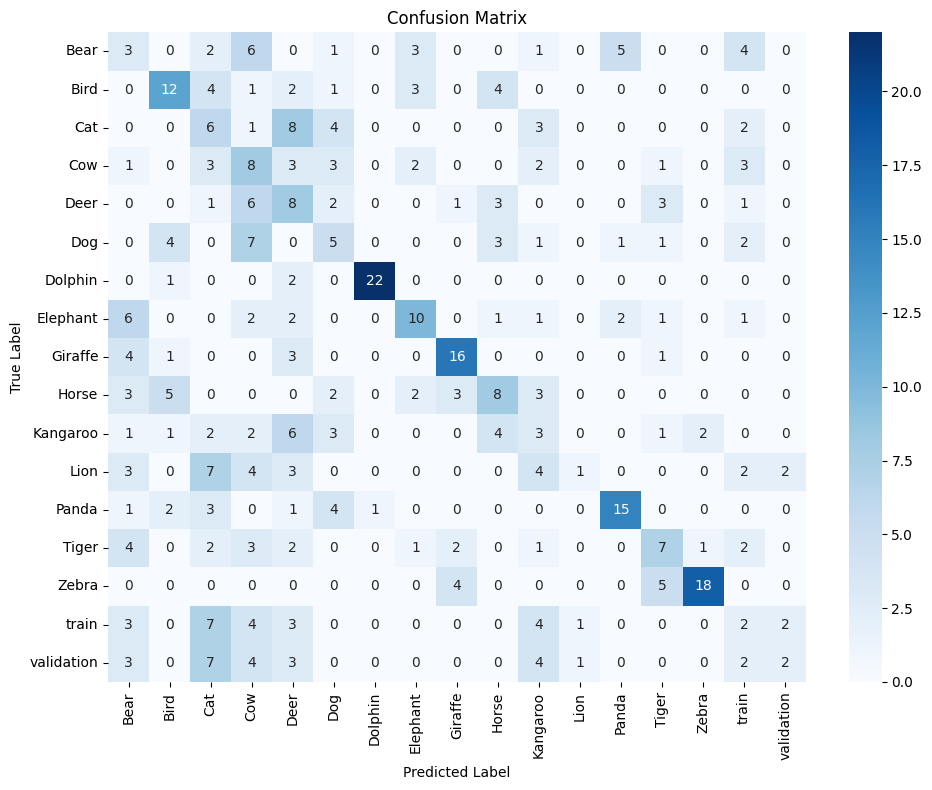

In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Get all predictions and true labels from validation set
y_true = []
y_pred = []

# Loop through the validation generator
val_generator.reset()
for i in range(len(val_generator)):
    x_batch, y_batch = val_generator[i]
    preds = model.predict(x_batch)
    
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Class labels
class_labels = list(val_generator.class_indices.keys())

# ✅ Accuracy Score
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {acc:.2f}")

# ✅ Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# ✅ Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
